# Session 2: Support Vector Machines (SVM) for Fake News Detection

**Fake News Detection on Twitter — Model Landscape, Part 2**

By the end of this notebook you will be able to:
- Explain the idea of a **maximum-margin** decision boundary, geometrically and mathematically
- Identify what **support vectors** are and why only they matter
- Train and evaluate a linear SVM on the same TF-IDF tweet data from Session 1
- Compare SVM against Logistic Regression on identical data

> **Recap:** in Session 1 we trained Logistic Regression, which asks *"what's the probability this tweet is fake?"* and learns weights by minimizing log loss. SVM is also a **linear classifier** working on the same TF-IDF vectors — but it asks a different question entirely, rooted in geometry rather than probability.

## 0. Setup

We rebuild the exact same dataset and TF-IDF pipeline from Session 1, so this notebook can run completely standalone. In your actual workflow, you'd typically keep one shared notebook/dataset across both sessions.

In [14]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [15]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)
print("Libraries loaded.")

Libraries loaded.


In [16]:


df = pd.read_csv("cleaned_fake_news_dataset.csv")

print("Loaded shape:", df.shape)
print(df.head())


# ============================================================
# TRAIN/TEST SPLIT — before vectorizing, to avoid data leakage
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    df["final_text"], df["label_num"],
    test_size=0.2, random_state=42, stratify=df["label_num"]
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


# ============================================================
# TF-IDF VECTORIZATION
# ============================================================
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

Loaded shape: (38590, 3)
                                          final_text label  label_num
0  st century wire say ben stein reputable profes...  Fake          1
1  washington reuters u president donald trump re...  Real          0
2  reuters puerto rico governor ricardo rossello ...  Real          0
3  monday donald trump embarrassed country accide...  Fake          1
4  glasgow scotland reuters u presidential candid...  Real          0
Train size: 30872
Test size: 7718
TF-IDF matrix shape (train): (30872, 5000)
TF-IDF matrix shape (test): (7718, 5000)


In [17]:
# def clean_text(text):
#     text = text.lower()
#     text = re.sub(r"http\S+|www\S+", "", text)
#     text = re.sub(r"#\w+", "", text)
#     text = re.sub(r"@\w+", "", text)
#     text = re.sub(r"[^a-z\s]", "", text)
#     text = re.sub(r"\s+", " ", text).strip()
#     return text

# df['clean_text'] = df['text'].apply(clean_text)
# df['label_num'] = df['label'].map({'Real': 0, 'Fake': 1})

# X_train, X_test, y_train, y_test = train_test_split(
#     df['clean_text'], df['label_num'],
#     test_size=0.2, random_state=42, stratify=df['label_num']
# )

# vectorizer = TfidfVectorizer(max_features=3000)
# X_train_tfidf = vectorizer.fit_transform(X_train)
# X_test_tfidf = vectorizer.transform(X_test)

# print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
# print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

In [18]:
# Quick recap: retrain Logistic Regression so we have it as a comparison point later
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
print("Logistic Regression accuracy (recap):", accuracy_score(y_test, lr_pred))

Logistic Regression accuracy (recap): 0.9861363047421612


## 1. A Different Question

Logistic Regression asked: *"What's the probability this tweet is fake?"* and fit a line by minimizing log loss.

**SVM asks a geometric question instead:**

> "What is the line (or hyperplane) that separates Real and Fake tweets by the **widest possible margin**?"

There's no probability involved at all in the basic formulation — just geometry. Let's build intuition with a toy 2D example before going anywhere near real text data.

## 2. Building Intuition: The Widest Street

Imagine two clusters of points on a 2D plane — one cluster is "Real" tweets, one is "Fake" tweets (simplified to just 2 features for visualization). There are **infinitely many lines** that could separate them correctly. Which one should we pick?

**SVM's answer:** pick the line that has the biggest possible "street" (margin) on either side before hitting a data point. Wider margin → more confidence that the boundary will still classify new, unseen points correctly.

The points that lie exactly on the edges of this street are called **support vectors** — they are the *only* points that determine where the boundary goes. Every other point could be deleted from the training set and the boundary wouldn't move at all.

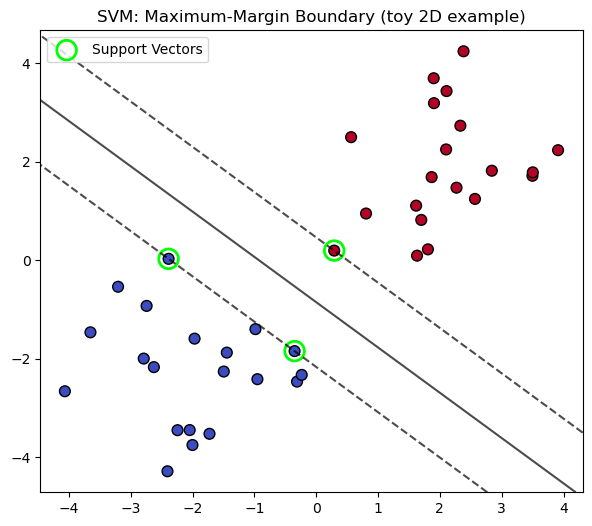

Number of support vectors: 3 out of 40 total points
This means only 3 points actually decide where the line goes.


In [19]:
# Toy 2D example purely for visualization/intuition — NOT the real tweet data
from sklearn.svm import SVC as SVC_demo

np.random.seed(7)
X_toy = np.r_[np.random.randn(20, 2) - [2, 2], np.random.randn(20, 2) + [2, 2]]
y_toy = [0]*20 + [1]*20   # 0 = Real (blue), 1 = Fake (red)

clf_toy = SVC_demo(kernel='linear', C=1000)  # large C ~ hard margin for a clean illustration
clf_toy.fit(X_toy, y_toy)

# Plot the decision boundary, margin, and support vectors
plt.figure(figsize=(7, 6))
plt.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, cmap='coolwarm', s=60, edgecolors='k')

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf_toy.decision_function(xy).reshape(XX.shape)

# Decision boundary (Z=0) and the two margins (Z=-1, Z=1)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.7,
           linestyles=['--', '-', '--'])

# Highlight the support vectors
ax.scatter(clf_toy.support_vectors_[:, 0], clf_toy.support_vectors_[:, 1],
           s=200, facecolors='none', edgecolors='lime', linewidths=2,
           label='Support Vectors')

plt.title("SVM: Maximum-Margin Boundary (toy 2D example)")
plt.legend()
plt.show()

print("Number of support vectors:", len(clf_toy.support_vectors_), "out of", len(X_toy), "total points")
print("This means only", len(clf_toy.support_vectors_), "points actually decide where the line goes.")

**Discussion point for students:** circle in green = support vectors. Solid line = the decision boundary. Dashed lines = the margins. Notice that points far from the boundary (in the solid colored regions) have **zero influence** on where the line sits — only the points closest to the other class matter.

## 3. The Math: Margin Maximization

### Step 1 — The decision boundary

Just like Logistic Regression, SVM defines a linear boundary:

$$f(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b$$

But instead of squashing this through a sigmoid, SVM uses it directly:
- If $f(\mathbf{x}) > 0$ → predict class 1 (Fake)
- If $f(\mathbf{x}) < 0$ → predict class 0 (Real)

### Step 2 — Defining the margin

SVM wants the two classes to lie outside two parallel boundary lines:

$$\mathbf{w}^T \mathbf{x} + b \geq +1 \quad \text{for Fake examples}$$
$$\mathbf{w}^T \mathbf{x} + b \leq -1 \quad \text{for Real examples}$$

The distance between these two parallel lines (the **margin width**) can be shown geometrically to equal:

$$\text{margin} = \frac{2}{\lVert \mathbf{w} \rVert}$$

To make the margin as *wide* as possible, we need $\lVert \mathbf{w} \rVert$ to be as *small* as possible. So the core optimization problem is:

$$\min_{\mathbf{w}, b} \frac{1}{2}\lVert \mathbf{w} \rVert^2 \quad \text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \ \ \forall i$$

This says: *minimize the size of the weight vector, while still correctly classifying every training point with a margin of at least 1.*

### Step 3 — What about points that can't be perfectly separated?

Real text data is messy — some tweets will sit right at the boundary or even on the wrong side. We allow some violations using **slack variables** $\xi_i \geq 0$, and a penalty parameter $C$:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\lVert \mathbf{w} \rVert^2 + C \sum_{i=1}^{m} \xi_i$$

This is the **soft-margin SVM** — almost always what's used in practice.

### Step 4 — The role of $C$ (the parameter you'll actually tune)

| | Small $C$ | Large $C$ |
|---|---|---|
| Margin | Wider | Narrower |
| Tolerance for misclassified points | High | Low |
| Risk | Underfitting | Overfitting |
| Behavior | Prioritizes generalization | Prioritizes fitting training data exactly |

This is a direct instance of the **bias–variance tradeoff**: small $C$ → higher bias, lower variance; large $C$ → lower bias, higher variance.

### Step 5 — Why a *linear* kernel for text

SVM can use **kernels** (RBF, polynomial) to draw non-linear boundaries by implicitly mapping data into a higher-dimensional space. But for TF-IDF text data, which is *already* extremely high-dimensional (thousands of features) and sparse, a **linear kernel** almost always performs best and is dramatically cheaper to train. Non-linear kernels add computational cost with little to no accuracy benefit here — this is exactly why the original project benchmark used a linear-style SVM to get 94.8% accuracy.

## 4. Training a Linear SVM on Our Tweets

`scikit-learn` gives us two ways to do this:
- `SVC(kernel='linear')` — the general SVM implementation; also lets us inspect support vectors directly
- `LinearSVC()` — a specialized, much faster implementation for the linear-kernel case (preferred for large sparse text data in real projects)

We'll use both: `SVC` to inspect support vectors for teaching purposes, and `LinearSVC` for the "real" comparison against Logistic Regression.

In [20]:
# SVC with linear kernel — lets us inspect support vectors directly
svc_linear = SVC(kernel='linear', C=1.0)
svc_linear.fit(X_train_tfidf, y_train)

print("Number of support vectors:", svc_linear.support_vectors_.shape[0])
print("Out of total training tweets:", X_train_tfidf.shape[0])
print(f"-> Only {svc_linear.support_vectors_.shape[0] / X_train_tfidf.shape[0] * 100:.1f}% of training tweets actually shape the boundary.")

Number of support vectors: 3303
Out of total training tweets: 30872
-> Only 10.7% of training tweets actually shape the boundary.


In [21]:
# LinearSVC — faster, preferred for large sparse text datasets in practice
svm_model = LinearSVC(C=1.0, max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
print("LinearSVC trained.")

LinearSVC trained.


## 5. Evaluating the SVM

In [22]:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {rec_svm:.4f}")
print(f"F1-score:  {f1_svm:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred_svm, target_names=["Real", "Fake"]))

Accuracy:  0.9931
Precision: 0.9957
Recall:    0.9891
F1-score:  0.9924

Full classification report:
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      4238
        Fake       1.00      0.99      0.99      3480

    accuracy                           0.99      7718
   macro avg       0.99      0.99      0.99      7718
weighted avg       0.99      0.99      0.99      7718



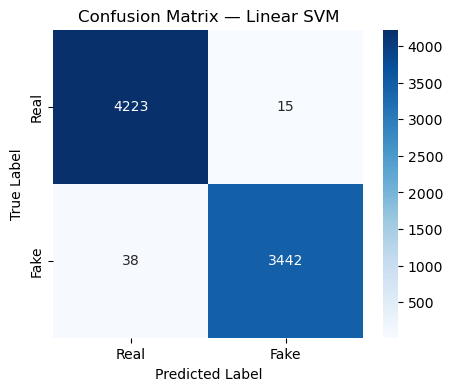

In [23]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Linear SVM")
plt.show()

## 6. Exploring the Effect of $C$

Let's make the bias–variance tradeoff concrete by training several SVMs with different values of $C$ and watching accuracy change.

In [24]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = []

for C in C_values:
    model = LinearSVC(C=C, max_iter=5000)
    model.fit(X_train_tfidf, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_tfidf))
    test_acc = accuracy_score(y_test, model.predict(X_test_tfidf))
    results.append({"C": C, "train_accuracy": train_acc, "test_accuracy": test_acc})

results_df = pd.DataFrame(results)
results_df

,C,train_accuracy,test_accuracy
0,0.001,0.930390,0.934569
1,0.010,0.976905,0.976030
2,0.100,0.992485,0.988987
3,1.000,0.998672,0.993133
4,10.000,1.000000,0.991967
5,100.000,1.000000,0.991578


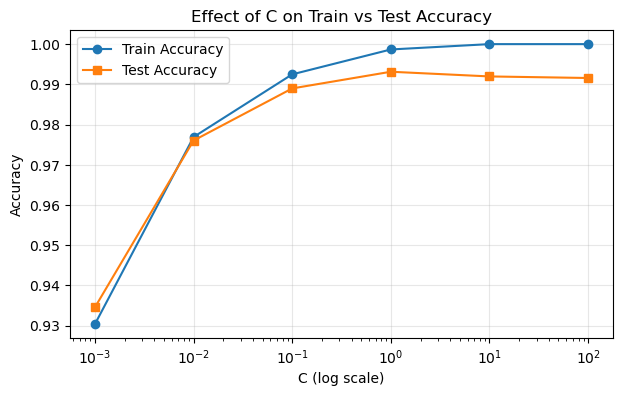

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(results_df['C'], results_df['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(results_df['C'], results_df['test_accuracy'], marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of C on Train vs Test Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Discussion point for students:** if training accuracy keeps climbing while test accuracy plateaus or drops as $C$ increases, that's overfitting in action — the margin is getting too narrow and fitting noise in the training tweets rather than the true signal.

## 7. Stress-Testing Both Models on Ambiguous Tweets

Our synthetic dataset is fairly clean, so both models may score close to 100%. Real tweets are messier. Let's manually create a few **deliberately tricky/ambiguous** tweets — the kind that sit near the decision boundary — and see how each model handles them, including its confidence.

In [28]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

tricky_tweets = [
    "Officials say the shocking new policy will secretly raise taxes next year",     # mixes "official" + "shocking/secretly"
    "This new study confirms a surprising link between sleep and the truth about memory",  # mixes "confirms/study" + "surprising/truth"
    "BREAKING the central bank officially confirmed the secret interest rate hike",  # mixes alarmist framing + real institutional language
    "Reuters reports a shocking truth officials dont want you to know about the budget",  # deliberately blended
    "The university study found no link between vaccines and the conspiracy theories online",  # negation makes this tricky
]

tricky_clean = [clean_text(t) for t in tricky_tweets]
tricky_tfidf = vectorizer.transform(tricky_clean)

lr_preds = lr_model.predict(tricky_tfidf)
lr_probs = lr_model.predict_proba(tricky_tfidf)[:, 1]
svm_preds = svm_model.predict(tricky_tfidf)
svm_scores = svm_model.decision_function(tricky_tfidf)  # distance from the boundary, not a probability

comparison = pd.DataFrame({
    "tweet": tricky_tweets,
    "LR_prediction": pd.Series(lr_preds).map({0: "Real", 1: "Fake"}),
    "LR_P(Fake)": np.round(lr_probs, 3),
    "SVM_prediction": pd.Series(svm_preds).map({0: "Real", 1: "Fake"}),
    "SVM_distance_from_boundary": np.round(svm_scores, 3),
})
comparison

,tweet,LR_prediction,LR_P(Fake),SVM_prediction,SVM_distance_from_boundary
0,Officials say the shocking new policy will sec...,Fake,0.805,Fake,0.820
1,This new study confirms a surprising link betw...,Fake,0.863,Fake,1.022
2,BREAKING the central bank officially confirmed...,Fake,0.722,Fake,0.661
3,Reuters reports a shocking truth officials don...,Real,0.105,Real,-2.567
4,The university study found no link between vac...,Fake,0.753,Fake,0.694


**Note on `decision_function` vs `predict_proba`:** SVM's `decision_function` returns the signed distance from the boundary ($f(\mathbf{x}) = \mathbf{w}^T\mathbf{x}+b$), *not* a probability. A larger positive number means "further into Fake territory, more confident"; close to zero means "right at the boundary, uncertain." This is a good moment to highlight a real conceptual difference: **Logistic Regression natively gives you probabilities; standard SVM does not** (it can be approximated via Platt scaling, but that's outside this scope).

## 8. Head-to-Head: Logistic Regression vs SVM

Let's put both models' metrics side by side on the same test set, the same way the project's benchmark slide does.

In [29]:
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [accuracy_score(y_test, lr_pred), accuracy_score(y_test, y_pred_svm)],
    "Precision": [precision_score(y_test, lr_pred), precision_score(y_test, y_pred_svm)],
    "Recall": [recall_score(y_test, lr_pred), recall_score(y_test, y_pred_svm)],
    "F1-score": [f1_score(y_test, lr_pred), f1_score(y_test, y_pred_svm)],
})
comparison_table

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.986136,0.990119,0.979023,0.98454
1,Linear SVM,0.993133,0.995661,0.989080,0.99236


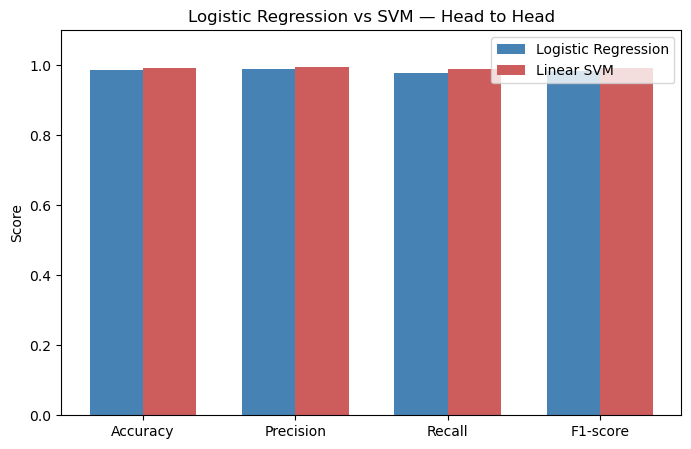

In [30]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, comparison_table.iloc[0, 1:], width, label='Logistic Regression', color='steelblue')
ax.bar(x + width/2, comparison_table.iloc[1, 1:], width, label='Linear SVM', color='indianred')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Logistic Regression vs SVM — Head to Head")
ax.legend()
plt.show()

**Important framing for your students (and directly relevant to the project deck's 92.4% vs 94.8% benchmark):** a small accuracy gap between two strong linear models is not, by itself, strong evidence that one model is "better" in any deep sense. It can easily shift with a different train/test split or a slightly larger dataset. The more useful takeaway is:

- **Both linear models are well-suited to TF-IDF text data** — this is the real lesson, not which one "wins" by a percentage point.
- **SVM's margin-maximization can sometimes generalize slightly better on borderline/ambiguous examples** — tweets that are sensational in tone but factually accurate, or dry in tone but actually misleading — because it explicitly optimizes the separation rather than fitting probabilities.
- In a real project, you'd want to check whether such a gap is **statistically significant** (e.g. via cross-validation with multiple folds) before concluding anything definitive.

## 9. A More Rigorous Comparison: Cross-Validation

A single train/test split can be misleading — the 92.4% vs 94.8% gap might just be luck of the split. Let's check both models across multiple folds.

In [32]:
from sklearn.model_selection import cross_val_score

X_all_tfidf = vectorizer.transform(df['final_text'])   
y_all = df['label_num']

lr_cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X_all_tfidf, y_all, cv=5, scoring='accuracy')
svm_cv_scores = cross_val_score(LinearSVC(max_iter=5000), X_all_tfidf, y_all, cv=5, scoring='accuracy')

print("Logistic Regression CV accuracy per fold:", np.round(lr_cv_scores, 4))
print(f"Logistic Regression mean accuracy: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")
print()
print("Linear SVM CV accuracy per fold:", np.round(svm_cv_scores, 4))
print(f"Linear SVM mean accuracy: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std():.4f})")

Logistic Regression CV accuracy per fold: [0.9828 0.9859 0.9856 0.9865 0.9861]
Logistic Regression mean accuracy: 0.9854 (+/- 0.0013)

Linear SVM CV accuracy per fold: [0.9914 0.9922 0.9926 0.993  0.9933]
Linear SVM mean accuracy: 0.9925 (+/- 0.0006)


**Teaching takeaway:** if the standard deviations of the two models' cross-validation scores overlap substantially, you cannot confidently claim one model outperforms the other on this data — the difference is within noise. This is exactly the kind of rigor that turns a project from "we tried 3 models and picked the best number" into "we evaluated 3 models and made a defensible choice."

## 10. Summary

| Concept | Key Idea |
|---|---|
| Core question | Find the hyperplane with the **maximum margin** between classes |
| Support vectors | Only the closest points to the boundary determine it — everything else is irrelevant to the boundary's position |
| Hard vs soft margin | Soft margin (with slack variables $\xi_i$) allows some misclassification for better generalization |
| $C$ parameter | Controls the margin-width vs misclassification-tolerance tradeoff (bias–variance) |
| Kernel choice | Linear kernel is standard for sparse, high-dimensional TF-IDF text — non-linear kernels rarely help and cost more |
| Output | A signed distance from the boundary, not a probability (unlike Logistic Regression's sigmoid output) |
| Why it works for text | Same reasons as Logistic Regression (sparse, high-dim, often linearly separable) — plus an explicit focus on margin robustness |

### What's next
With both Logistic Regression and SVM covered, your students now have two strong linear baselines. The natural next steps in the course are:
1. **Naive Bayes** — a fast probabilistic alternative, useful as a third point of comparison
2. **Performance Metrics deep-dive** — formalizing precision/recall/F1 trade-offs in the context of *which kind of error matters more* for fake news detection (a missed fake tweet vs. wrongly flagging a real one)
3. Building the **final comparison table** that mirrors the project deck's benchmark slide, now backed by cross-validated numbers rather than a single split.